<a href="https://colab.research.google.com/github/omnateeta/Machine-Learning-Lab/blob/main/Untitled7b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score,mean_squared_error

In [26]:
df=sns.load_dataset("mpg")
print(df)

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin                       name  
0            70     usa  chevrolet chevelle malibu  
1            70     usa      

In [8]:
df=df.dropna()

In [13]:
x=df["horsepower"].values.reshape(-1,1)
y=df["mpg"].values
x=x.astype(float)
poly=PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

In [15]:
model=LinearRegression()
model.fit(x_poly,y)

LinearRegression()

In [17]:
y_pred=model.predict(x_poly)
r2=r2_score(y,y_pred)
mse=mean_squared_error(y,y_pred)

R2 Score: 0.6875590305127517
Mean Squared Error: 18.98476890761722 ; 18.984769


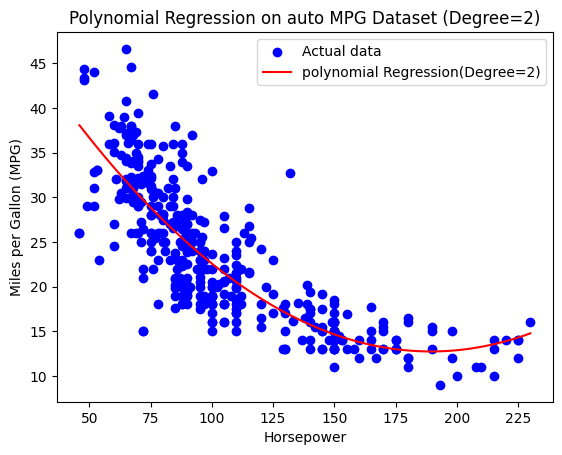

In [25]:
print(f"R2 Score: {r2}")
print(f"Mean Squared Error: {mse} ; {mse:4f}")
x_range=np.linspace(x.min(), x.max(), 100).reshape(-1,1) # Corrected xmax() to x.max()
x_range_poly=poly.transform(x_range) # Separated transformation
y_range_pred=model.predict(x_range_poly) # Separated prediction
plt.scatter(x,y,color='blue',label="Actual data")
plt.plot(x_range,y_range_pred,color="red",label="polynomial Regression(Degree=2)")
plt.xlabel("Horsepower")
plt.ylabel("Miles per Gallon (MPG)")
plt.title("Polynomial Regression on auto MPG Dataset (Degree=2)")
plt.legend()
plt.show()